In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os
from collections import Counter

print("✅ All imports successful!")

✅ All imports successful!


In [2]:
# Update this path to where YOUR data folder is
DATA_PATH = "../data"   # goes up one level from notebooks/ into data/

class_names = {
    "0": "Clean Sea / No Oil",
    "1": "Oil Spill"
}

print("📊 DATASET SUMMARY")
print("="*40)
total = 0
for cls in ["0", "1"]:
    path = os.path.join(DATA_PATH, cls)
    count = len(os.listdir(path))
    total += count
    label = class_names[cls]
    bar = "█" * (count // 100)
    print(f"Class {cls} ({label}): {count} images  {bar}")

print("="*40)
print(f"Total images: {total}")
print(f"Imbalance ratio: {round(3543/866, 1)}:1 (clean:oil)")

📊 DATASET SUMMARY
Class 0 (Clean Sea / No Oil): 3543 images  ███████████████████████████████████
Class 1 (Oil Spill): 866 images  ████████
Total images: 4409
Imbalance ratio: 4.1:1 (clean:oil)


C:\Users\DELL\AppData\Local\Temp\ipykernel_23540\3150482040.py:21: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\DELL\AppData\Local\Temp\ipykernel_23540\3150482040.py:21: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\DELL\AppData\Local\Temp\ipykernel_23540\3150482040.py:21: UserWarning: Glyph 127754 (\N{WATER WAVE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\DELL\AppData\Local\Temp\ipykernel_23540\3150482040.py:22: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig("dataset_preview.png", dpi=150, bbox_inches='tight')
C:\Users\DELL\AppData\Local\Temp\ipykernel_23540\3150482040.py:22: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig("dataset_preview.png", dpi=150, bbox_inches='tight')
C:\Users\DELL\AppData\Local\Temp\ipykernel_23540\315048

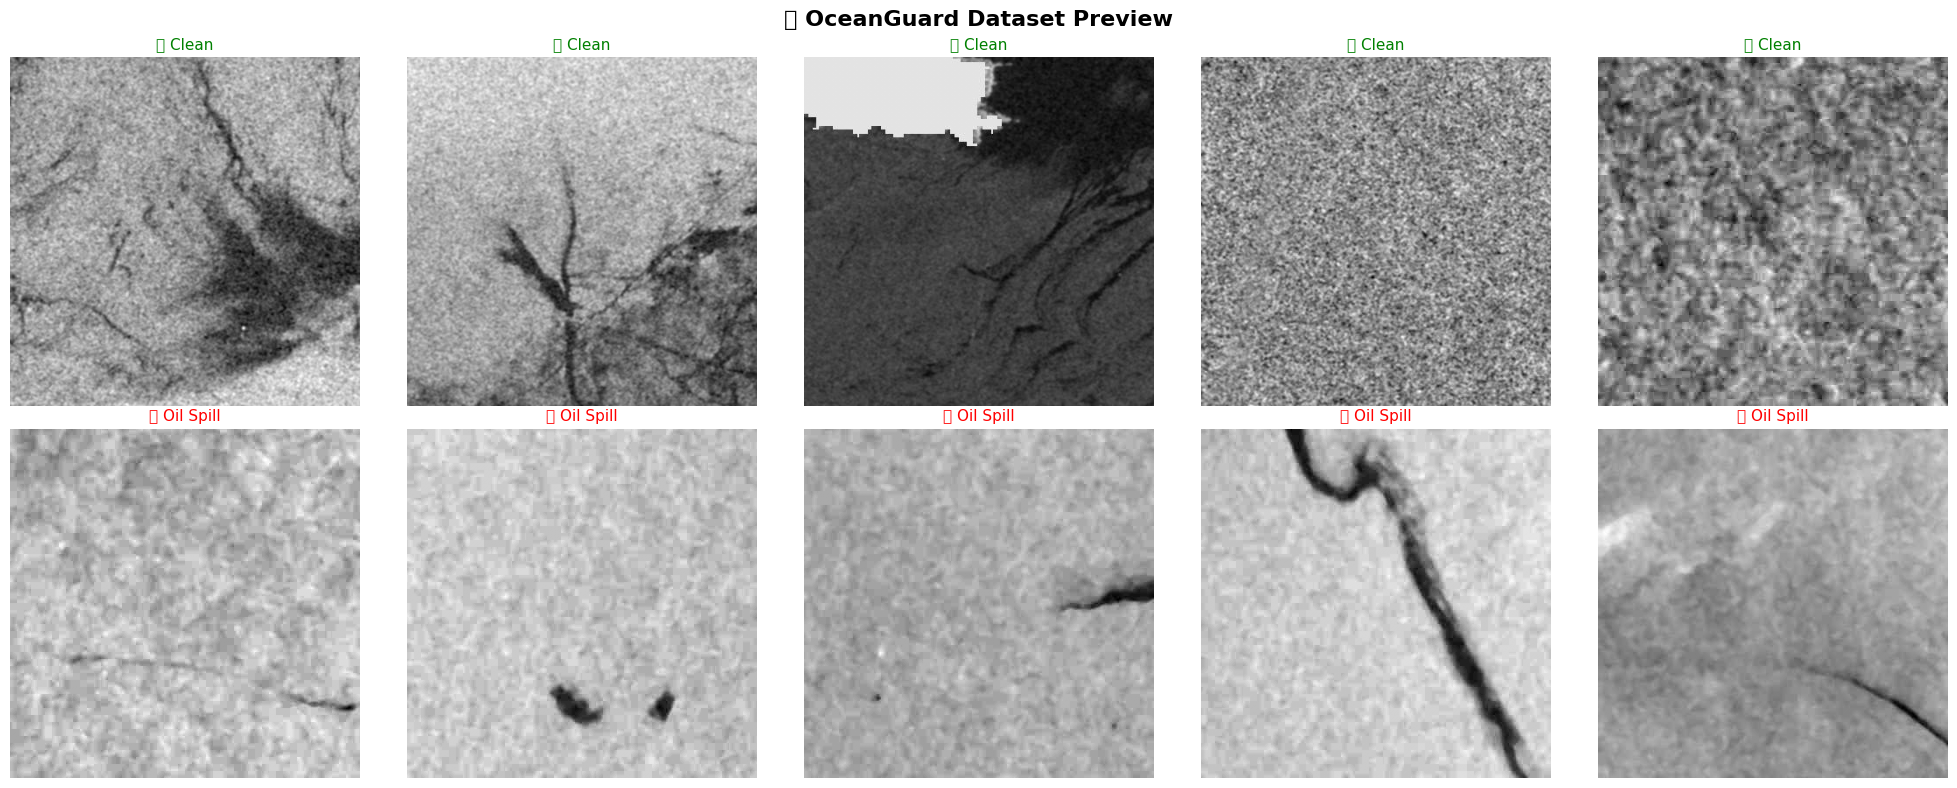

Preview saved! ✅


In [3]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
fig.suptitle("🌊 OceanGuard Dataset Preview", fontsize=16, fontweight='bold')

for row, cls in enumerate(["0", "1"]):
    folder = os.path.join(DATA_PATH, cls)
    files = os.listdir(folder)[:5]
    
    for col, fname in enumerate(files):
        img_path = os.path.join(folder, fname)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        img = cv2.resize(img, (400, 400))
        
        axes[row][col].imshow(img, cmap='gray')
        axes[row][col].set_title(
            f"{'🟢 Clean' if cls=='0' else '🔴 Oil Spill'}", 
            fontsize=11,
            color='green' if cls=='0' else 'red'
        )
        axes[row][col].axis('off')

plt.tight_layout()
plt.savefig("dataset_preview.png", dpi=150, bbox_inches='tight')
plt.show()
print("Preview saved! ✅")

In [4]:
# Check what our images actually look like technically
sample_path = os.path.join(DATA_PATH, "1", os.listdir(os.path.join(DATA_PATH, "1"))[0])
sample = cv2.imread(sample_path, cv2.IMREAD_GRAYSCALE)

print("📐 IMAGE PROPERTIES")
print("="*40)
print(f"Shape: {sample.shape}")
print(f"Data type: {sample.dtype}")
print(f"Min pixel value: {sample.min()}")
print(f"Max pixel value: {sample.max()}")
print(f"Mean pixel value: {sample.mean():.2f}")
print("="*40)
print("These are GRAYSCALE SAR images (1 channel)")
print("Pixel values 0-255 represent radar backscatter intensity")

📐 IMAGE PROPERTIES
Shape: (400, 400)
Data type: uint8
Min pixel value: 83
Max pixel value: 112
Mean pixel value: 104.00
These are GRAYSCALE SAR images (1 channel)
Pixel values 0-255 represent radar backscatter intensity


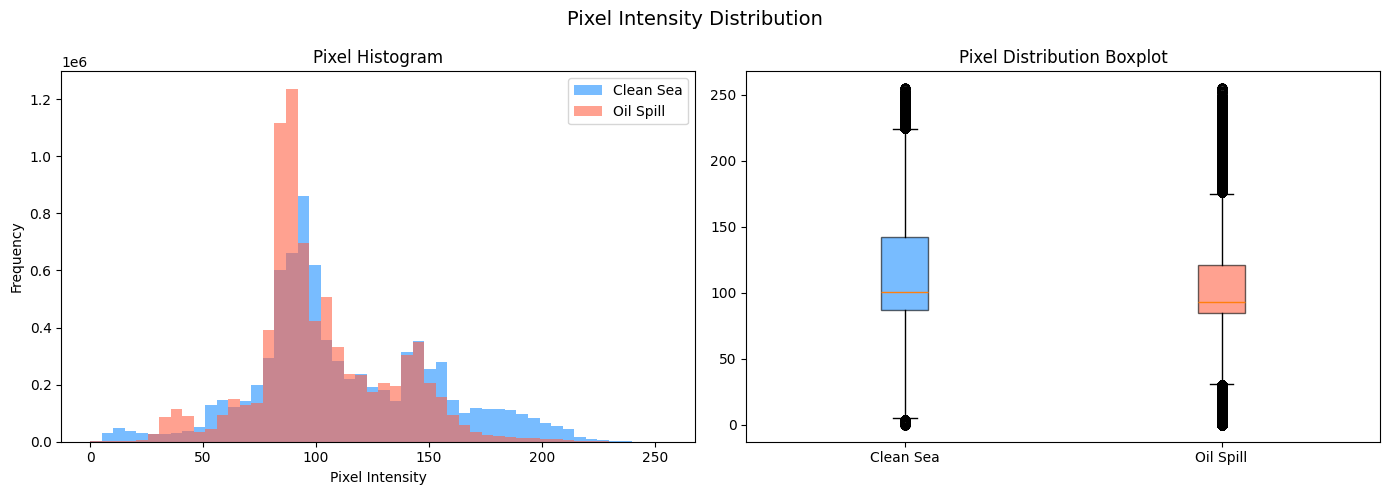

💡 KEY INSIGHT: Oil spills appear DARKER in SAR images
   (lower radar backscatter = darker pixels = oil dampens waves)


In [5]:
# Compare how oil vs clean looks pixel-wise
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Pixel Intensity Distribution", fontsize=14)

colors = {'0': 'dodgerblue', '1': 'tomato'}
labels = {'0': 'Clean Sea', '1': 'Oil Spill'}

for cls in ['0', '1']:
    folder = os.path.join(DATA_PATH, cls)
    all_pixels = []
    
    # Sample 50 images per class
    for fname in os.listdir(folder)[:50]:
        img = cv2.imread(os.path.join(folder, fname), cv2.IMREAD_GRAYSCALE)
        all_pixels.extend(img.flatten().tolist())
    
    axes[0].hist(all_pixels, bins=50, alpha=0.6, 
                 color=colors[cls], label=labels[cls])
    axes[1].boxplot([all_pixels], positions=[int(cls)], 
                    patch_artist=True,
                    boxprops=dict(facecolor=colors[cls], alpha=0.6))

axes[0].set_title("Pixel Histogram")
axes[0].set_xlabel("Pixel Intensity")
axes[0].set_ylabel("Frequency")
axes[0].legend()

axes[1].set_title("Pixel Distribution Boxplot")
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['Clean Sea', 'Oil Spill'])

plt.tight_layout()
plt.show()

print("💡 KEY INSIGHT: Oil spills appear DARKER in SAR images")
print("   (lower radar backscatter = darker pixels = oil dampens waves)")

In [6]:
print("📋 EDA COMPLETE — READY FOR TRAINING")
print("="*50)
print(f"✅ Total images: 4,409")
print(f"✅ Image size: 400x400 pixels (grayscale)")  
print(f"✅ Classes: 2 (Clean Sea, Oil Spill)")
print(f"⚠️  Class imbalance: 3543 vs 866")
print()
print("🔧 TRAINING PLAN:")
print("  - Resize images to 128x128 (faster training)")
print("  - Use class_weight to fix imbalance")
print("  - CNN with BatchNorm (energy efficient = Green AI ✅)")
print("  - Target accuracy: >90%")
print()
print("➡️  Next: Open 02_Training.ipynb")

📋 EDA COMPLETE — READY FOR TRAINING
✅ Total images: 4,409
✅ Image size: 400x400 pixels (grayscale)
✅ Classes: 2 (Clean Sea, Oil Spill)
⚠️  Class imbalance: 3543 vs 866

🔧 TRAINING PLAN:
  - Resize images to 128x128 (faster training)
  - Use class_weight to fix imbalance
  - CNN with BatchNorm (energy efficient = Green AI ✅)
  - Target accuracy: >90%

➡️  Next: Open 02_Training.ipynb
